<a href="https://colab.research.google.com/github/rahiakela/computer-vision-research-and-practice/blob/main/vision-language-models/02_minimal_vlm_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Dataset

In [1]:
!wget https://huggingface.co/datasets/vlmbook/notebooks/raw/main/Chapter%203/create_fig_3_1.py -O create_fig_3_1.py

--2026-09-02 05:49:16--  https://huggingface.co/datasets/vlmbook/notebooks/raw/main/Chapter%203/create_fig_3_1.py
Resolving huggingface.co (huggingface.co)... 18.164.174.118, 18.164.174.23, 18.164.174.55, ...
Connecting to huggingface.co (huggingface.co)|18.164.174.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7056 (6.9K) [text/plain]
Saving to: ‘create_fig_3_1.py’

create_fig_3_1.py   100%[===================>]   6.89K  --.-KB/s    in 0s      

2026-09-02 05:49:17 (1.63 GB/s) - ‘create_fig_3_1.py’ saved [7056/7056]



In [2]:
from datasets import load_dataset

dataset = load_dataset("HuggingFaceM4/FineVisionMax", split="train", streaming=True)
print(next(iter(dataset)))

README.md:   0%|          | 0.00/4.25k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/10000 [00:00<?, ?it/s]

{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=1506x1102 at 0x785E2A142990>], 'texts': [{'user': 'What is the primary key of the Equipment entity?', 'assistant': 'The primary key of the Equipment entity is EquipmentID, which uniquely identifies each piece of equipment in the diagram.\nAnswer: EquipmentID'}, {'user': 'What is the relationship between Equipment and Maintenance Record?', 'assistant': 'The relationship between Equipment and Maintenance Record is labeled as "Maintained By", indicating that one piece of equipment can have multiple maintenance records associated with it.\nAnswer: Maintained By'}, {'user': 'How many relationships does the Supplier entity have?', 'assistant': 'The Supplier entity has two relationships: "Supplied By" with Equipment and "Delivered By" with Logistics Company, indicating it serves as a midpoint in both flows.\nAnswer: 2'}, {'user': 'What is the cardinality of the relationship between Equipment and Supplier?', 'assistant': 'The car

```python
from create_fig_3_1 import normalize_conversations, extract_sample_image, render_imessage

count = 0
for sample in dataset:
    if count >= 50:
        break
    try:
        sample_image = extract_sample_image(sample).convert("RGB")
        conversations = normalize_conversations(sample, max_turns=2)
    except (KeyError, ValueError):
        continue
    render_imessage(sample_image, conversations, filename=f"imessage_style_{count:02d}.png")
    count += 1

print(f"Done — saved {count} images.")
```

## Create VLM architecture

We are using here simpler autoregressive stack(with a simple projector
handing information from vision into text) and cross-attention (lots of back-andforth
attention ping-ponging between the two).

In [3]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoProcessor, AutoTokenizer, AutoModelForCausalLM

class VisionLanguageModel(nn.Module):
    def __init__(self, vision_encoder_ckpt, language_model_ckpt, modality_input_dim=768, modality_output_dim=576):
        super().__init__()
        # only take vision backbone
        self.vision_encoder = AutoModel.from_pretrained(vision_encoder_ckpt).vision_model
        self.vision_processor = AutoProcessor.from_pretrained(vision_encoder_ckpt)
        self.modality_projector = nn.Linear(modality_input_dim, modality_output_dim, bias=False)
        self.tokenizer = AutoTokenizer.from_pretrained(language_model_ckpt)
        self.llm = AutoModelForCausalLM.from_pretrained(language_model_ckpt)

    def forward(self, text, image, labels=None):
        processed_img = self.vision_processor(images=[image], return_tensors="pt").to(self.llm.device)
        image_embd = self.vision_encoder(**processed_img).last_hidden_state
        image_embd = self.modality_projector(image_embd).to(dtype=self.llm.dtype)  # match LLM dtype

        input_ids = self.tokenizer(text, return_tensors="pt").input_ids.to(self.llm.device)
        token_embd = self.llm.model.embed_tokens(input_ids)

        # Concatenate image embeddings to token embeddings
        combined_embd = torch.cat((image_embd, token_embd), dim=1)

        logits = self.llm(inputs_embeds=combined_embd).logits

        shift_logits = logits[:, image_embd.size(1):-1, :].contiguous()
        shift_labels = input_ids[:, 1:].contiguous()

        loss = nn.functional.cross_entropy(shift_logits.reshape(-1, shift_logits.size(-1)), shift_labels.reshape(-1))

        return logits, loss

See how simple this implementation is? Let’s break it down:

**The vision path (processor -> encoder -> projector)**
- This takes a raw image and turns it into a neat little sequence of embeddings
the LLM can understand. Think of it as translating pixels into “token-flavored”
vectors.

**The text path (tokenizer -> embedder)**
- Classic LLM territory. We tokenize the text, look up the embeddings, and get a
sequence of text vectors ready to go.

**The glue**
- Here’s where the autoregressive magic kicks in. We just concatenate the projected
image embeddings with the text embeddings and call it a day. The LLM then
processes the whole thing as one long token sequence. No special rules for image
tokens, no fancy routing, nothing exotic. Just vibes and matrix multiplications.

<div class="alert alert-block alert-info">
<b>Note:</b> This autoregressive VLM doesn’t actually know which tokens came
from text and which came from the image. It’s intentionally simple:
project, concatenate, predict. The real challenge is teaching the
model to make this mixed stream meaningful.
</div>

**Calculating Loss**

We only care about predicting the text tokens that come after
the image. So we will drop the logits that correspond to the image positions and
compute the loss only on the text part.

```python
logits = self.llm(inputs_embeds=combined_embd).logits

shift_logits = logits[:, image_embd.size(1):-1, :].contiguous()
shift_labels = input_ids[:, 1:].contiguous()

loss = nn.functional.cross_entropy(shift_logits.reshape(-1, shift_logits.size(-1)), shift_labels.reshape(-1))

return logits, loss
```

But you might be wondering: Why do we use cross entropy as the loss function here?

Cross entropy is the standard loss for language modeling. At each position, the model
outputs a probability distribution over the entire vocabulary. Cross entropy measures
how “surprised” that distribution is about the true next token.

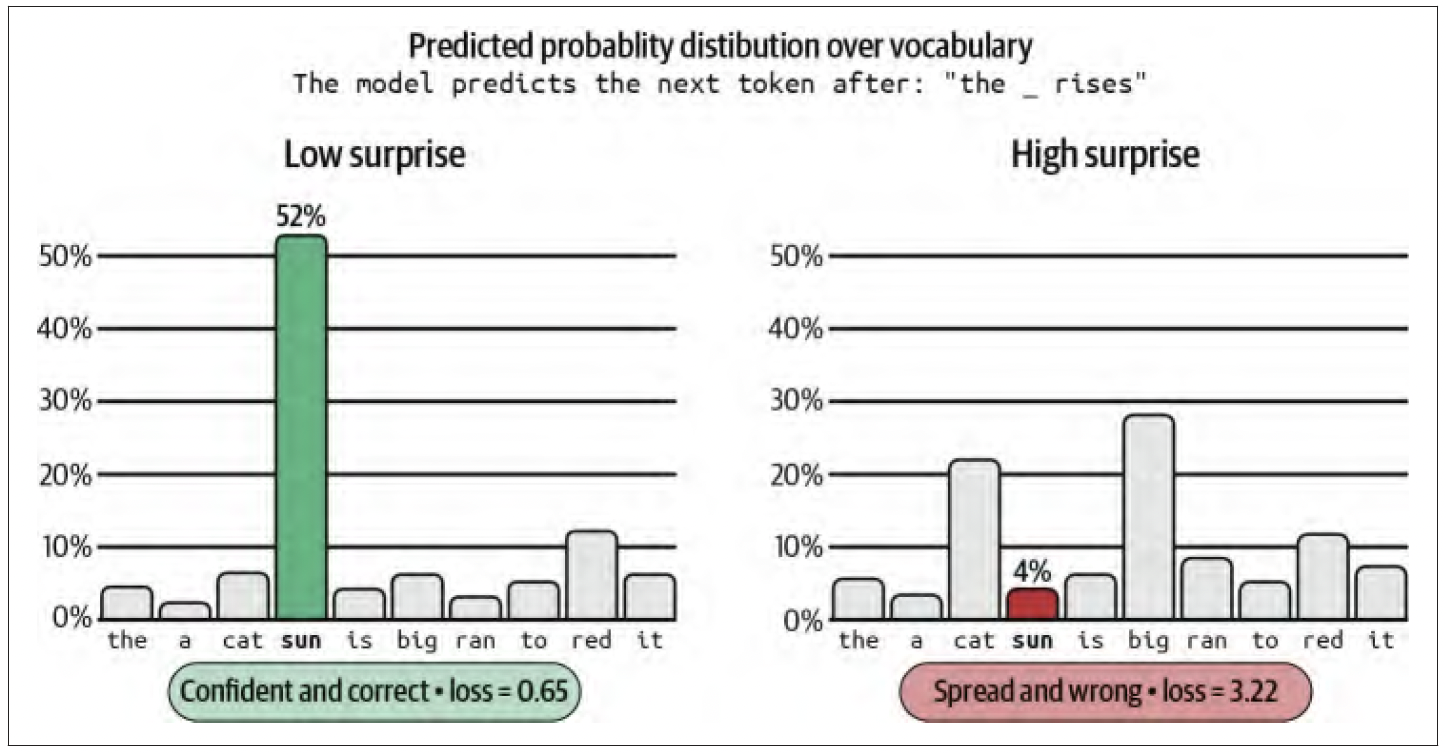

Now that we have a loss, our VLM is finally trainable. Let’s grab a sample image from
the dataset, apply the chat template, and run a single forward pass to sanity-check
that everything connects:

In [4]:
vision_encoder_ckpt = "google/siglip2-base-patch16-256"
language_model_ckpt = "HuggingFaceTB/SmolLM2-135M-Instruct"

vlm = VisionLanguageModel(vision_encoder_ckpt, language_model_ckpt).to("cuda")

config.json:   0%|          | 0.00/276 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  269MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [5]:
from transformers.image_utils import load_image

image = load_image("https://huggingface.co/datasets/merve/coco/resolve/main/val2017/000000000285.jpg")
text = "What does this say?"
vlm(text, image)

(tensor([[[16.8750,  8.5625, 12.3750,  ...,  9.9375, 13.3125,  5.2500],
          [18.6250,  9.0000, 13.6875,  ..., 16.2500, 16.5000, 11.8125],
          [12.6875,  3.3594,  8.2500,  ...,  8.7500, 10.3750,  7.4062],
          ...,
          [18.0000,  7.5938, 11.7500,  ..., 15.8125, 16.1250, 13.4375],
          [ 8.8750,  1.3594,  5.7500,  ...,  5.5000, 10.0625,  5.2188],
          [12.9375, 10.9375, 17.1250,  ...,  9.6250, 12.0000,  9.6250]]],
        device='cuda:0', dtype=torch.bfloat16, grad_fn=<UnsafeViewBackward0>),
 tensor(4.1250, device='cuda:0', dtype=torch.bfloat16,
        grad_fn=<NllLossBackward0>))

In [6]:
sample = next(iter(dataset))

def apply_chat_template_to_sample(sample):
  messages_list = []
  for data_dict in sample['texts']:
      messages_list.append({'role': 'user', 'content': data_dict['user']})
      messages_list.append({'role': 'assistant', 'content': data_dict['assistant']})
  text = vlm.tokenizer.apply_chat_template(messages_list, tokenize=False)
  return text

text = apply_chat_template_to_sample(sample)


In [7]:
sample

{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=1506x1102>],
 'texts': [{'user': 'What is the primary key of the Equipment entity?',
   'assistant': 'The primary key of the Equipment entity is EquipmentID, which uniquely identifies each piece of equipment in the diagram.\nAnswer: EquipmentID'},
  {'user': 'What is the relationship between Equipment and Maintenance Record?',
   'assistant': 'The relationship between Equipment and Maintenance Record is labeled as "Maintained By", indicating that one piece of equipment can have multiple maintenance records associated with it.\nAnswer: Maintained By'},
  {'user': 'How many relationships does the Supplier entity have?',
   'assistant': 'The Supplier entity has two relationships: "Supplied By" with Equipment and "Delivered By" with Logistics Company, indicating it serves as a midpoint in both flows.\nAnswer: 2'},
  {'user': 'What is the cardinality of the relationship between Equipment and Supplier?',
   'assistant': 'The ca

In [ ]:
text

'<|im_start|>system\nYou are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>\n<|im_start|>user\nWhat is the primary key of the Equipment entity?<|im_end|>\n<|im_start|>assistant\nThe primary key of the Equipment entity is EquipmentID, which uniquely identifies each piece of equipment in the diagram.\nAnswer: EquipmentID<|im_end|>\n<|im_start|>user\nWhat is the relationship between Equipment and Maintenance Record?<|im_end|>\n<|im_start|>assistant\nThe relationship between Equipment and Maintenance Record is labeled as "Maintained By", indicating that one piece of equipment can have multiple maintenance records associated with it.\nAnswer: Maintained By<|im_end|>\n<|im_start|>user\nHow many relationships does the Supplier entity have?<|im_end|>\n<|im_start|>assistant\nThe Supplier entity has two relationships: "Supplied By" with Equipment and "Delivered By" with Logistics Company, indicating it serves as a midpoint in both flows.\nAnswer: 2<|im_end|>\n<|im_start|>

In [ ]:
vlm(text, sample['images'])

(tensor([[[17.5000,  8.8750, 12.7500,  ..., 10.5625, 13.8750,  5.8750],
          [19.6250, 13.7500, 18.2500,  ..., 16.1250, 17.8750, 12.6250],
          [14.4375,  8.5000, 14.1875,  ..., 15.0000, 12.0000,  6.6875],
          ...,
          [18.6250, 26.0000, 33.2500,  ..., 15.7500, 11.3750, 10.2500],
          [25.8750, 27.6250, 29.3750,  ..., 13.6875, 14.0000, 12.0625],
          [14.7500, 32.0000, 32.2500,  ..., 11.3750,  9.4375,  8.8750]]],
        device='cuda:0', dtype=torch.bfloat16, grad_fn=<UnsafeViewBackward0>),
 tensor(1.9219, device='cuda:0', dtype=torch.bfloat16,
        grad_fn=<NllLossBackward0>))

## Training model

In [ ]:
import json
import torch.optim as optim
optimizer = optim.AdamW(vlm.parameters(), lr=1e-5)

step = 0
losses = []
for sample in dataset:
    text = apply_chat_template_to_sample(sample)
    if len(text) > 3000 or len(sample['images']) != 1:
      continue
    images = [sample['images'][0].convert('RGB')]
    step += 1

    optimizer.zero_grad()
    # computes the loss
    logits, loss = vlm(text, images)
    losses.append(loss)

    # backpropagate
    loss.backward()
    # updates the parameters
    optimizer.step()

    if step%100 == 0:
        print(f"step {step} | loss {loss.item():.4f}")

    if step > 5000:
      json.dump([round(l.item(), 4) for l in losses], open("chapter_3_loss.json", "w"))
      break

step 100 | loss 1.9531
step 200 | loss 3.2500
step 300 | loss 2.1719
step 400 | loss 5.1562
step 500 | loss 2.5469
step 600 | loss 2.5625
step 700 | loss 1.3281
step 800 | loss 1.0156
step 900 | loss 1.6016
step 1000 | loss 1.6016
step 1100 | loss 2.4844
step 1200 | loss 1.6094
step 1300 | loss 2.0781
step 1400 | loss 1.0625
step 1500 | loss 0.9180
step 1600 | loss 1.4922
step 1700 | loss 2.2656
step 1800 | loss 1.3750
step 1900 | loss 2.5938
step 2000 | loss 1.9453
step 2100 | loss 0.6484
step 2200 | loss 0.7812
step 2300 | loss 1.5000
step 2400 | loss 2.3281
step 2500 | loss 2.2812
step 2600 | loss 1.6719
step 2700 | loss 2.0469
step 2800 | loss 2.4375
step 2900 | loss 0.7500
step 3000 | loss 3.6094
step 3100 | loss 4.0625
step 3200 | loss 1.7578
step 3300 | loss 2.2656
step 3400 | loss 1.6250
step 3500 | loss 2.4375
step 3600 | loss 1.7734
step 3700 | loss 1.9141


So, super cool, we are training our first VLM! But there are several
things missing from this implementation that would be useful.

Here are three:
* Why are we using batch size one? Wouldn’t we want more?
* Now I want to evaluate it by asking it questions
and seeing what it replies. Can I do it with this implementation?
* We’re using tiny 256 × 256 images right now. How many vision tokens is that?
What happens with high-resolution images?

## Traing with batch size

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer

dataset = load_dataset("HuggingFaceM4/FineVisionMax", split="train", streaming=True)
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")

def tokenize_sample(sample):
    messages_list = []
    for data_dict in sample['texts']:
        messages_list.append({'role': 'user', 'content': data_dict['user']})
        messages_list.append({'role': 'assistant', 'content': data_dict['assistant']})
    tokens = tokenizer.apply_chat_template(messages_list, tokenize=True)
    return tokens['input_ids']

max_length = 2048
curr_sample = []
batch = []
max_batch_size = 8
for sample in dataset:
    tokens = tokenize_sample(sample)
    if len(tokens) > max_length:
        continue  # Skip samples that are too long
    if len(curr_sample) + len(tokens) < max_length:
        curr_sample.extend(tokens)
    else:
        if len(batch) == max_batch_size:
            break # We've reached the max batch size, so we need to break
        batch.append(curr_sample)
        curr_sample = tokens

Resolving data files:   0%|          | 0/10000 [00:00<?, ?it/s]

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoProcessor, AutoTokenizer, AutoModelForCausalLM

class VisionLanguageModel(nn.Module):
    def __init__(self, vision_encoder_ckpt, language_model_ckpt, tokenizer, modality_input_dim=768, modality_output_dim=576):
        super().__init__()
        self.vision_encoder = AutoModel.from_pretrained(vision_encoder_ckpt).vision_model
        self.vision_processor = AutoProcessor.from_pretrained(vision_encoder_ckpt)
        self.modality_projector = nn.Linear(modality_input_dim, modality_output_dim, bias=False)
        self.tokenizer = tokenizer # AutoTokenizer.from_pretrained(language_model_ckpt, extra_special_tokens={"image_token": "<|image|>"})
        self.llm = AutoModelForCausalLM.from_pretrained(language_model_ckpt)
        self.llm.resize_token_embeddings(len(self.tokenizer))  # Resize the LLM's token embeddings to match the tokenizer's new vocab size

    def _replace_img_tokens_with_embd(self, input_ids, token_embd, image_embd):
        """
        Replace every image-token placeholder in `input_ids` with the corresponding slice
        from `image_embd`. Supports an arbitrary number of image-token placeholders per sample.
        The first example in the batch might have 2 images and the second none.
        """
        # Clone the original embeddings to avoid in-place issues
        updated_token_embd = token_embd.clone()

        # Build a mask of all image-token positions: shape [B, T_seq]
        mask = (input_ids == self.tokenizer.image_token_id)
        updated_token_embd[mask] = image_embd.view(-1, image_embd.size(-1)).to(updated_token_embd.dtype) # torch flattens before assigning

        return updated_token_embd

    def forward(self, input_ids, image):
        processed_img = self.vision_processor(images=[image], return_tensors="pt").to(self.llm.device)
        image_embd = self.vision_encoder(**processed_img).last_hidden_state
        image_embd = self.modality_projector(image_embd)

        token_embd = self.llm.model.embed_tokens(input_ids)
        combined_embd = self._replace_img_tokens_with_embd(input_ids, token_embd, image_embd)

        logits = self.llm(inputs_embeds=combined_embd).logits

        # 1. Create labels from the input_ids
        labels = input_ids.clone()

        # 2. We don't want to compute loss on image tokens.
        #    Set them to the ignore_index (which is pad_token_id).
        labels[labels == self.tokenizer.image_token_id] = self.tokenizer.pad_token_id

        # 3. Standard next-token-prediction shifting:
        #    The logit at index `i` predicts the token at index `i+1`
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        # 4. Compute loss, ignoring all tokens marked with pad_token_id
        #    (this now includes both padding AND image tokens)
        loss = nn.functional.cross_entropy(
            shift_logits.reshape(-1, shift_logits.size(-1)),
            shift_labels.reshape(-1),
            ignore_index=self.tokenizer.pad_token_id
        )

        return logits, loss

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer
import torch.optim as optim
import time
import json
import numpy as np

vision_encoder_ckpt = "google/siglip2-base-patch16-256"
language_model_ckpt = "HuggingFaceTB/SmolLM2-135M-Instruct"
dataset = load_dataset("HuggingFaceM4/FineVisionMax", split="train", streaming=True)
tokenizer = AutoTokenizer.from_pretrained(language_model_ckpt, extra_special_tokens={"image_token": "<|image|>"})
vlm = VisionLanguageModel(vision_encoder_ckpt, language_model_ckpt, tokenizer).to("cuda")
optimizer = optim.AdamW(vlm.parameters(), lr=1e-4)

def tokenize_sample(sample):
    messages_list = []
    for data_dict in sample['texts']:
        messages_list.append({'role': 'user', 'content': data_dict['user']})
        messages_list.append({'role': 'assistant', 'content': data_dict['assistant']})
    messages_list[0]['content'] = tokenizer.image_token*256 + messages_list[0]['content']  # add image tokens
    tokens = tokenizer.apply_chat_template(messages_list, tokenize=True)
    return tokens['input_ids']

step = 0
losses = []
max_length = 2048
curr_sample = []
curr_image = []
batch = []
image_batch = []
max_batch_size = 4
batch_complete = False
start = time.time()
for sample in dataset:
    if len(sample['images']) != 1:
      continue
    tokens = tokenize_sample(sample)
    if len(tokens) > max_length:
        continue  # Skip samples that are too long
    if len(curr_sample) + len(tokens) < max_length:
        curr_sample.extend(tokens)
        curr_image.extend([sample['images'][0].convert('RGB')])
    else:
        batch.append(torch.nn.functional.pad(torch.Tensor(curr_sample), (max_length - len(curr_sample),0), 'constant', tokenizer.pad_token_id))
        image_batch.extend(curr_image)
        if len(batch) == max_batch_size:
          batch_complete = True # We've reached the max batch size, so we can continue
        curr_sample = tokens
        curr_image = [sample['images'][0].convert('RGB')]
    if batch_complete:
      step += 1
      if step%100 == 0:
        print(f"step {step} | loss {loss.item():.4f} | smoothed loss: {np.mean(losses[-10:]):.4f}")
        print(f"The last 100 steps took: {time.time()-start:.2f} seconds.")
        start = time.time()

      optimizer.zero_grad()
      logits, loss = vlm(torch.stack(batch).long().cuda(), image_batch)
      losses.append(loss.item())

      loss.backward()
      optimizer.step()

      batch_complete = False
      batch = []
      image_batch = []
      if step > 5000:
        break

json.dump([round(l, 4) for l in losses], open("chapter_3_batched_loss.json", "w"))

Resolving data files:   0%|          | 0/10000 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (28674 > 8192). Running this sequence through the model will result in indexing errors


step 100 | loss 1.4531 | smoothed loss: 1.5258
The last 100 steps took: 91.58 seconds.
step 200 | loss 1.4609 | smoothed loss: 1.4172
The last 100 steps took: 93.71 seconds.
step 300 | loss 1.5703 | smoothed loss: 1.3359
The last 100 steps took: 93.15 seconds.
step 400 | loss 1.5156 | smoothed loss: 1.3262
The last 100 steps took: 93.01 seconds.
step 500 | loss 1.0859 | smoothed loss: 1.2203
The last 100 steps took: 73.74 seconds.
step 600 | loss 1.3281 | smoothed loss: 1.3719
The last 100 steps took: 96.48 seconds.
step 700 | loss 0.6992 | smoothed loss: 1.2375
The last 100 steps took: 92.60 seconds.
step 800 | loss 1.2656 | smoothed loss: 1.3758
The last 100 steps took: 95.97 seconds.
step 900 | loss 1.1484 | smoothed loss: 1.2699
The last 100 steps took: 84.72 seconds.
step 1000 | loss 1.5000 | smoothed loss: 1.3703
The last 100 steps took: 75.39 seconds.
step 1100 | loss 0.8594 | smoothed loss: 1.0289
The last 100 steps took: 85.08 seconds.
step 1200 | loss 1.4141 | smoothed loss: 

In [ ]:
json.dump([round(l, 4) for l in losses], open("chapter_3_batched_loss.json", "w"))

In [ ]:
from transformers.image_utils import load_image

image = load_image("https://huggingface.co/datasets/merve/coco/resolve/main/val2017/000000002006.jpg")

def generate(trained_vlm, tokenizer, input_text, image, max_new_tokens):
    text = [{"role": "user", "content": tokenizer.image_token*256 + input_text}]
    text_str = tokenizer.apply_chat_template(text, add_generation_prompt=True, tokenize=False)
    input_tokens = tokenizer(text_str, return_tensors="pt").input_ids.cuda()
    next_token = None
    output = []
    end_of_sentence_token = tokenizer.eos_token_id

    while len(output) < max_new_tokens:
        prediction = trained_vlm(input_tokens, image)[0]
        next_token = torch.argmax(prediction[:, -1, :])
        if next_token == end_of_sentence_token:
            break
        output.append(next_token)
        input_tokens = torch.cat([input_tokens, next_token[None, None]], dim=1)

    return ''.join(tokenizer.batch_decode(output))

print(generate(vlm, tokenizer, "What do you see here?", image, 32))
